In [1]:
import numpy as np
import matplotlib.pyplot as plt

import utils

Number of samples = 99733
Number of samples after thinning = 665
Number of samples = 118686
Number of samples after thinning = 792
Number of samples = 100169
Number of samples after thinning = 668
Number of samples = 102845
Number of samples after thinning = 686


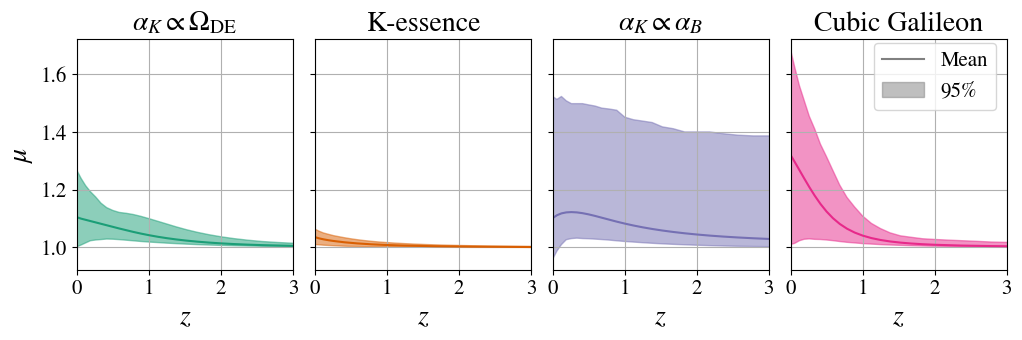

In [2]:
indices = range(68, 72)
names = ["omega", "kessence", "prop", "cugal"]
titles = ["$\\alpha_K \\propto \\Omega_\\mathrm{DE}$", "K-essence", "$\\alpha_K \\propto \\alpha_B$", "Cubic Galileon"]
aktypes = [1, 2, 4, 3]

fig, axs = plt.subplots(1, 4, sharey=True, sharex=True, figsize=(12,3), gridspec_kw={"wspace": 0.1})
for i, (chain_index, name, aktype, color) in enumerate(zip(indices, names, aktypes, utils.colors)):
    chain = utils.load_chain(chain_index, burn_in=0.3)
    log_a, alpha_B, alpha_K, mus = utils.get_mu_alphas_from_chain(chain, aktype=aktype, thin_factor=150)
    z = 10**-log_a - 1
    axs[i].plot(z, np.mean(mus, axis=0), color=color)
    # axs[i].plot(z, np.percentile(mus, 16, axis=0),   color=color, ls="--", alpha=0.8)
    # axs[i].plot(z, np.percentile(mus, 84, axis=0),   color=color, ls="--", alpha=0.8)
    axs[i].fill_between(z, np.percentile(mus, 2.5, axis=0), np.percentile(mus, 97.5, axis=0), color=color,  alpha=0.5)
    # axs[i].plot(z, np.percentile(mus, 97.5, axis=0), color=color, ls="--",  alpha=0.8)
    
    del chain, alpha_B, alpha_K, mus

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

mean_line = Line2D([], [], ls="-", color="gray", label="Mean")
error_patch = Patch(color="gray", alpha=0.5, label="95%")

axs[0].set_ylabel("$\\mu$", fontsize=20)
for ax, title in zip(axs, titles):
    ax.set_xlim(0, 3)
    ax.grid()
    ax.set_xlabel("$z$", fontsize=20)
    ax.set_title(title, fontsize=20)
    ax.tick_params(axis="both", labelsize=15)

# fig.suptitle("Datasets: Planck PR4 + DESI DR2 BAO + DES-Dovekie SN")
fig.legend(handles=[mean_line, error_patch], fontsize=15, bbox_to_anchor=(0.9,0.9))
    
plt.savefig(f"plots/constraint_mu_ds1_subluminal_dyncs2.pdf", bbox_inches="tight")